In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Original analyzer for data loading
from src.analysis.summary import EEGSummarizedAnalyzer
from src.definitions.fields import (
    ExperimentNames,
    CoordinateSystems,
    ConditionVariants,
    MusicTypeVariants,
    ExclusionCategories,
    SingleDataMetadata,
)
from src.definitions.constants import ProjectPaths

# Modular analysis pipeline
from src.analysis.isc import compute_loo_isc, compute_sliding_window_isc, FREQUENCY_BANDS
from src.analysis.data_representations import (
    AnalysisData,
    DataRepresentation,
    to_analytic_amplitude,
    to_wavelet_amplitude,
    to_wavelet_power,
    to_mean_response,
)
from src.visualization.isc_plots import (
    plot_loo_isc_distribution,
    plot_sliding_window_isc,
    print_significant_intervals,
    plot_band_isc_distributions,
    plot_band_mean_isc_bar,
    plot_band_sliding_window_isc,
    print_band_significant_intervals,
    plot_band_overlap,
    print_data_overview,
)

from xvfbwrapper import Xvfb
vdisplay = Xvfb()
vdisplay.start()

%matplotlib inline

In [2]:
import pathlib

# Directory where all figures from this notebook are saved
SAVE_DIR = ProjectPaths.PLOTS_PATH / "OverallAnalysis"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {SAVE_DIR}")


Figures will be saved to: /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/plots/OverallAnalysis


In [3]:
# Broadband ISC threshold
ISC_THRESHOLD = 0.035

# Per-band ISC significance thresholds (Pearson r)
# Adjust each value independently as needed
BAND_ISC_THRESHOLDS = {
    "delta": 0.1,
    "theta": 0.07,
    "alpha": 0.035,
    "beta":  0.02,
    "gamma": 0.01,
}

# Sliding-window parameters
WINDOW_SEC = 5.0
STEP_SEC   = 2.5

## Setup

Create `EEGSummarizedAnalyzer` instances, load data, and convert to
`AnalysisData` containers.

The `AnalysisData` format supports swapping the **data representation**
(raw time-domain, ICA activations, wavelet amplitude/power, mean response, …)
while keeping all downstream analysis and visualisation code **identical**.

In [4]:
# process_and_save_data = True
process_and_save_data = False

def make_analyzer(music_type):
    """Create, load and normalise an analyzer for one music type."""
    a = EEGSummarizedAnalyzer(
        experiment_name=ExperimentNames.PSILO_MUSIC,
        coordinate_system=CoordinateSystems.HYDROGEL_257_NO_FIDUCIALS,
        music_types=[music_type],
        conditions=[ConditionVariants.PLACEBO],
        exclusion_categories=[ExclusionCategories.BAD_MUSIC],
    )
    if process_and_save_data:
        a.load_and_prepare_data(resample_freq=250.0, n_jobs=-1)
        print(f"[{music_type.value}] data shape: {a.data.shape}")
        a.save_data()
    else:
        a.load_data(
            info_filename=a.filtered_df[SingleDataMetadata.FILENAME].iloc[0],
        )
        print(f"[{music_type.value}] Loaded data shape: {a.data.shape}")
    a.normalize()
    return a

analyzer_classical = make_analyzer(MusicTypeVariants.CLASSICAL)
analyzer_psytrance = make_analyzer(MusicTypeVariants.PSYTRANCE)

# Ordered dict for easy iteration in all subsequent cells
analyzers = {
    "Classical": analyzer_classical,
    "Psytrance": analyzer_psytrance,
}

Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/../src/data/dataset_handler.py:173: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.
[CLASSIC] Loaded data shape: (16, 195, 91392)
Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif...


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/../src/data/dataset_handler.py:173: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


    Range : 23383 ... 508124 =     23.383 ...   508.124 secs
Ready.
[PSYTRANCE] Loaded data shape: (20, 195, 121186)


In [5]:
# ============================================================================
# REPRESENTATION SWITCH
# ============================================================================
# Change the active block below to run ALL subsequent analyses on a
# different data representation.  Everything downstream uses `datasets`.
# ============================================================================

# --- Option 1: Raw time-domain EEG (default) ---
datasets = {
    label: a.to_analysis_data(label=label)
    for label, a in analyzers.items()
}

# --- Option 2: Hilbert amplitude envelope (broadband) ---
# datasets = {
#     label: to_analytic_amplitude(a.to_analysis_data(label=label))
#     for label, a in analyzers.items()
# }

# --- Option 3: Wavelet amplitude (e.g. alpha band 8-13 Hz) ---
# freqs = np.arange(8, 14, 0.5)
# datasets = {
#     label: to_wavelet_amplitude(a.to_analysis_data(label=label), freqs=freqs)
#     for label, a in analyzers.items()
# }

# --- Option 4: Wavelet power (e.g. alpha band 8-13 Hz) ---
# freqs = np.arange(8, 14, 0.5)
# datasets = {
#     label: to_wavelet_power(a.to_analysis_data(label=label), freqs=freqs)
#     for label, a in analyzers.items()
# }

# --- Option 5: Mean response (half-split, for reliability) ---
# datasets = {
#     label: to_mean_response(
#         a.to_analysis_data(label=label), group_size=a.data.shape[0] // 2
#     )
#     for label, a in analyzers.items()
# }

# --- Option 6: ICA component activations ---
# datasets = {
#     label: a.load_and_prepare_ica_data(resample_freq=250.0, label=label)
#     for label, a in analyzers.items()
# }

# Summary
for label, ad in datasets.items():
    print(f"[{label}] {ad}")

[Classical] AnalysisData('Classical', time_domain, 16 items × 195 features × 91392 samples, sfreq=250.0)
[Psytrance] AnalysisData('Psytrance', time_domain, 20 items × 195 features × 121186 samples, sfreq=250.0)


## Analysis — Inter-Subject Correlation (ISC)

`compute_loo_isc` computes the leave-one-out ISC for every feature:
for each item *s*, the Pearson correlation between item *s* and the mean of all
other items is calculated. Returns per-item ISC `(n_items, n_features)` and
the item-mean `(n_features,)`.

All conditions are computed and shown side-by-side.
Works identically on any data representation selected above.

In [6]:
# Compute LOO-ISC for all datasets
loo_iscs = {}
mean_loo_iscs = {}
for label, ad in datasets.items():
    loo_isc, mean_loo_isc = compute_loo_isc(ad.data)
    loo_iscs[label] = loo_isc
    mean_loo_iscs[label] = mean_loo_isc
    print(f"[{label}]  loo_isc: {loo_isc.shape}   mean_loo_isc: {mean_loo_isc.shape}")

[Classical]  loo_isc: (16, 195)   mean_loo_isc: (195,)
[Psytrance]  loo_isc: (20, 195)   mean_loo_isc: (195,)


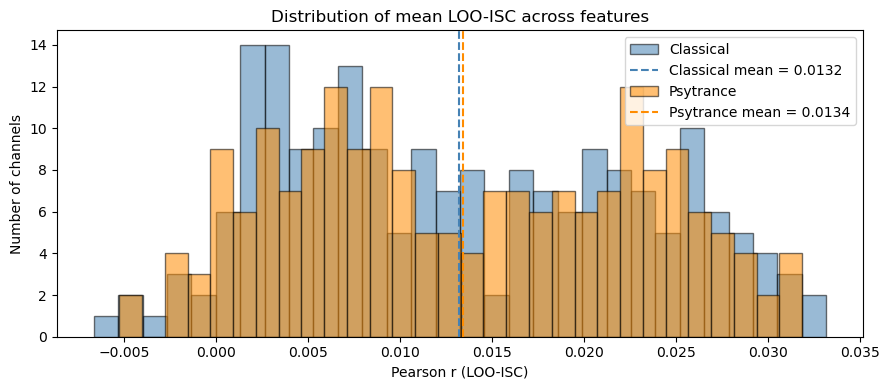

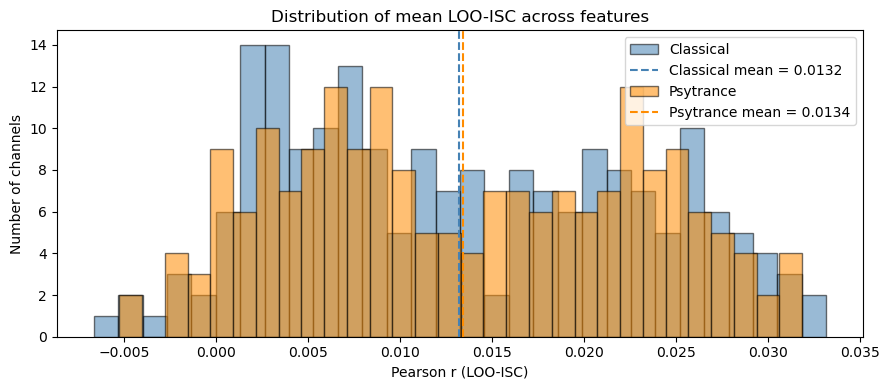

In [7]:
# Distribution of mean LOO-ISC — all conditions overlaid
_first_ad = next(iter(datasets.values()))

plot_loo_isc_distribution(
    mean_loo_iscs,
    ylabel=f"Number of {_first_ad.feature_axis_label.lower()}s",
    save_path=SAVE_DIR / "loo_isc_distribution.png",
)

## Data Overview

High-level summary of the loaded data array: number of subjects, channels, time-points, recording duration and sampling frequency.

In [8]:
# Data overview for all datasets
print_data_overview(datasets)

--- Classical (time_domain) ---
  Subjects : 16
  Channels: 195
  Samples      : 91392
  Sfreq        : 250.0 Hz
  Duration     : 365.6 s  (6.1 min)
  Data dtype   : float64
  Data range   : [-62.572, 48.960]

--- Psytrance (time_domain) ---
  Subjects : 20
  Channels: 195
  Samples      : 121186
  Sfreq        : 250.0 Hz
  Duration     : 484.7 s  (8.1 min)
  Data dtype   : float64
  Data range   : [-67.540, 48.453]



## Sliding-Window ISC (Time-Resolved Synchrony)

Instead of collapsing the entire recording into one ISC value, a sliding window
(default 5 s, step 2.5 s) is moved across time.  Inside each window the LOO-ISC
is computed and averaged across subjects, producing a time course of synchrony
per channel.  This reveals **when** during the music the listeners' brains are
most synchronised.

In [9]:
# Compute sliding-window ISC for all datasets
sw_results = {}
for label, ad in datasets.items():
    sw_isc, sw_times = compute_sliding_window_isc(
        ad.data, window_sec=WINDOW_SEC, step_sec=STEP_SEC, sfreq=ad.sfreq
    )
    sw_results[label] = (sw_isc, sw_times)
    print(f"[{label}]  sw_isc: {sw_isc.shape}   sw_times: {sw_times.shape}")

[Classical]  sw_isc: (145, 195)   sw_times: (145,)
[Psytrance]  sw_isc: (192, 195)   sw_times: (192,)


[Classical] Significant windows (r > 0.035): 13/145 (9.0 %)
[Psytrance] Significant windows (r > 0.035): 19/192 (9.9 %)


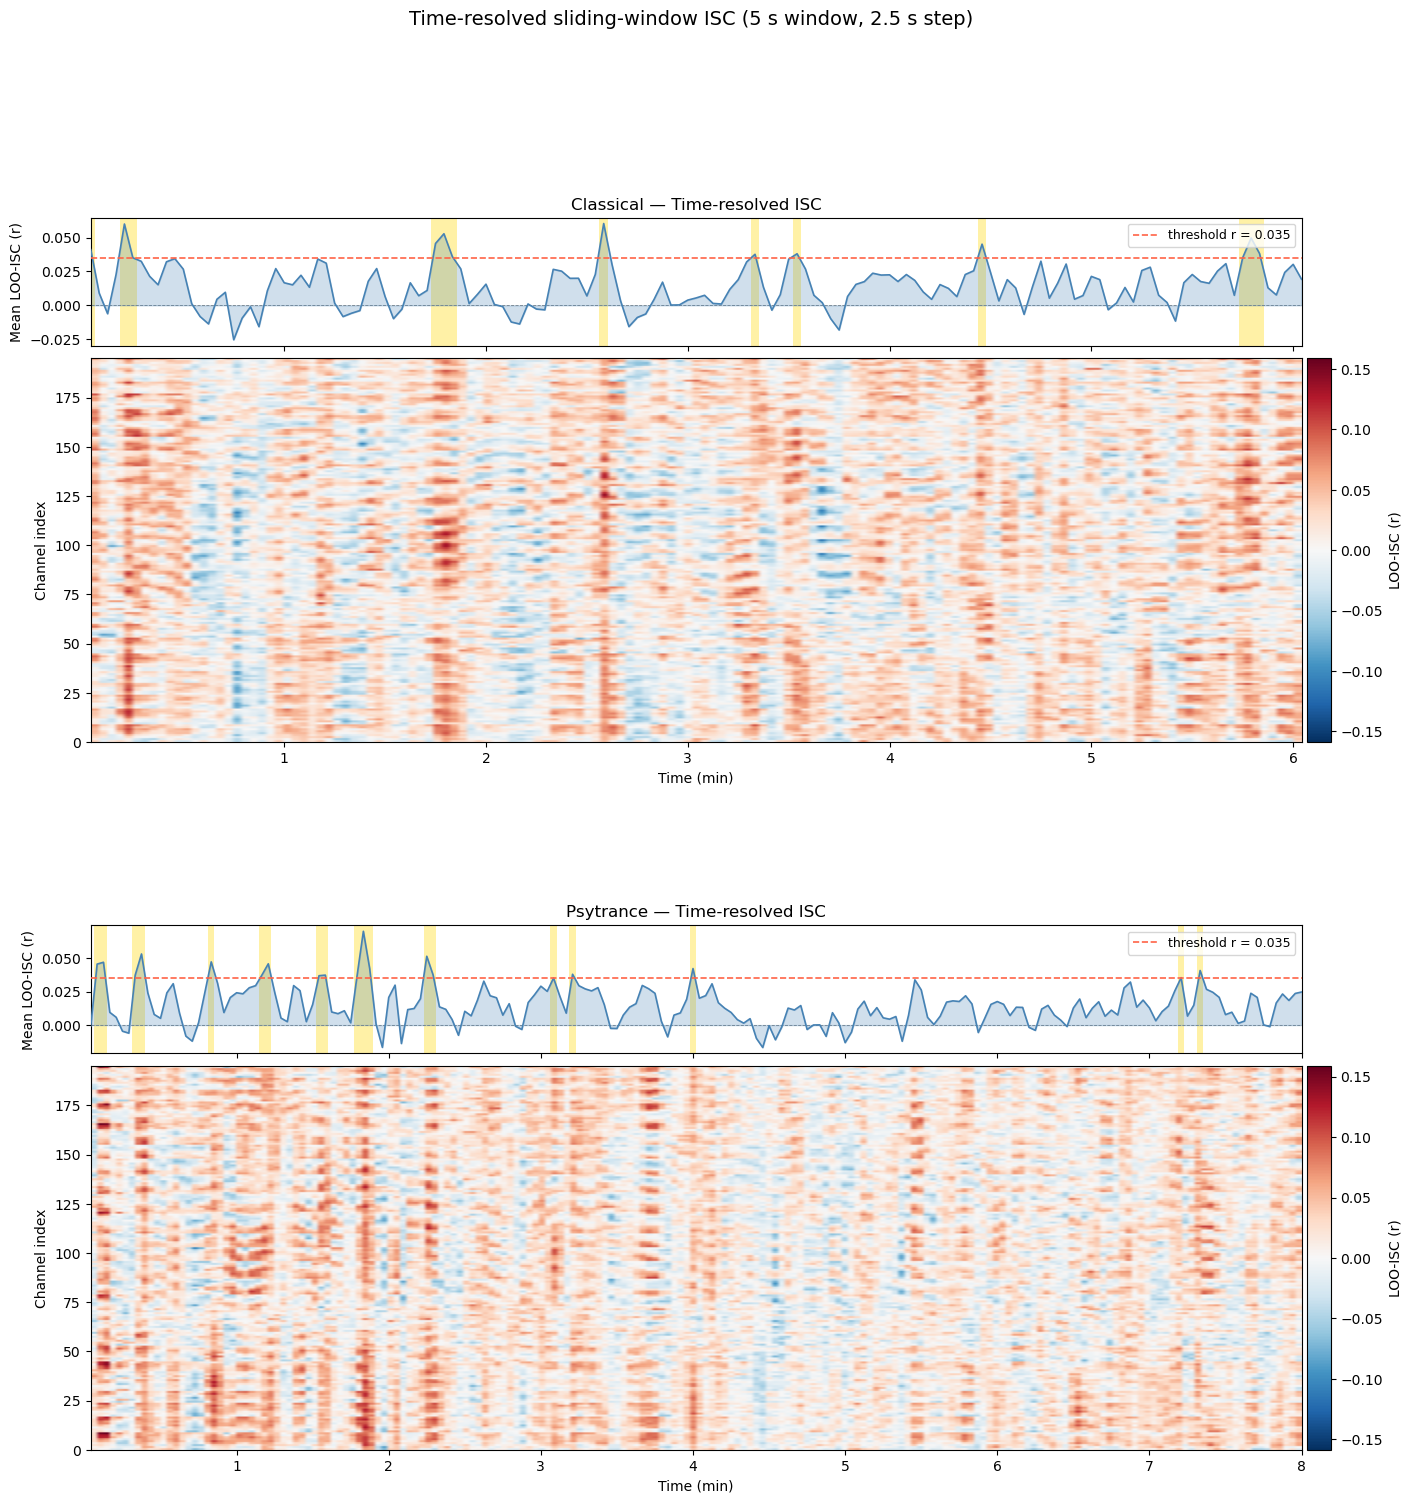

In [ ]:
_first_ad = next(iter(datasets.values()))

plot_sliding_window_isc(
    sw_results,
    isc_threshold=ISC_THRESHOLD,
    feature_axis_label=f"{_first_ad.feature_axis_label} index",
    save_path=SAVE_DIR / "sliding_window_isc.png",
)

In [ ]:
# Print contiguous significant intervals for all datasets
print_significant_intervals(sw_results, isc_threshold=ISC_THRESHOLD)

=== Classical ===
Threshold: r > 0.035   |   Significant windows: 13/145 (9.0 %)

  #  Start (min)  End (min)  Duration (s)    Mean r    Peak r
--------------------------------------------------------------
  1        0.021      0.062           2.5    0.0411    0.0411
  2        0.188      0.271           5.0    0.0475    0.0600
  3        1.729      1.854           7.5    0.0448    0.0528
  4        2.562      2.604           2.5    0.0603    0.0603
  5        3.312      3.354           2.5    0.0377    0.0377
  6        3.521      3.562           2.5    0.0380    0.0380
  7        4.438      4.479           2.5    0.0451    0.0451
  8        5.729      5.854           7.5    0.0410    0.0496

=== Psytrance ===
Threshold: r > 0.035   |   Significant windows: 19/192 (9.9 %)

  #  Start (min)  End (min)  Duration (s)    Mean r    Peak r
--------------------------------------------------------------
  1        0.062      0.146           5.0    0.0462    0.0469
  2        0.312      0.396

## Analysis — Band-specific ISC

LOO-ISC computed separately for each canonical EEG frequency band
(delta 1–4 Hz, theta 4–8 Hz, alpha 8–13 Hz, beta 13–30 Hz, gamma 30–70 Hz).
The broadband data is band-pass filtered with a Hamming-window FIR filter,
then ISC is computed as before.  This reveals which oscillatory components
drive inter-subject synchrony.


In [ ]:
# Compute per-band LOO-ISC for all datasets (band-pass filter + ISC)
band_iscs: dict = {}
for label, ad in datasets.items():
    print(f"Computing band ISC for {label} …")
    band_iscs[label] = {}
    for band, (l_freq, h_freq) in FREQUENCY_BANDS.items():
        filtered = ad.filter_to_band(l_freq, h_freq)
        loo, mean_isc = compute_loo_isc(filtered.data)
        band_iscs[label][band] = (loo, mean_isc)
        print(f"  {band:6s}  loo_isc={loo.shape}  mean={mean_isc.mean():.4f}")
    print()

Computing band ISC for Classical …
  delta   loo_isc=(16, 195)  mean=0.0315
  theta   loo_isc=(16, 195)  mean=0.0215
  alpha   loo_isc=(16, 195)  mean=0.0059
  beta    loo_isc=(16, 195)  mean=0.0022
  gamma   loo_isc=(16, 195)  mean=0.0011

Computing band ISC for Psytrance …
  delta   loo_isc=(20, 195)  mean=0.0350
  theta   loo_isc=(20, 195)  mean=0.0215
  alpha   loo_isc=(20, 195)  mean=0.0042
  beta    loo_isc=(20, 195)  mean=-0.0005
  gamma   loo_isc=(20, 195)  mean=0.0033



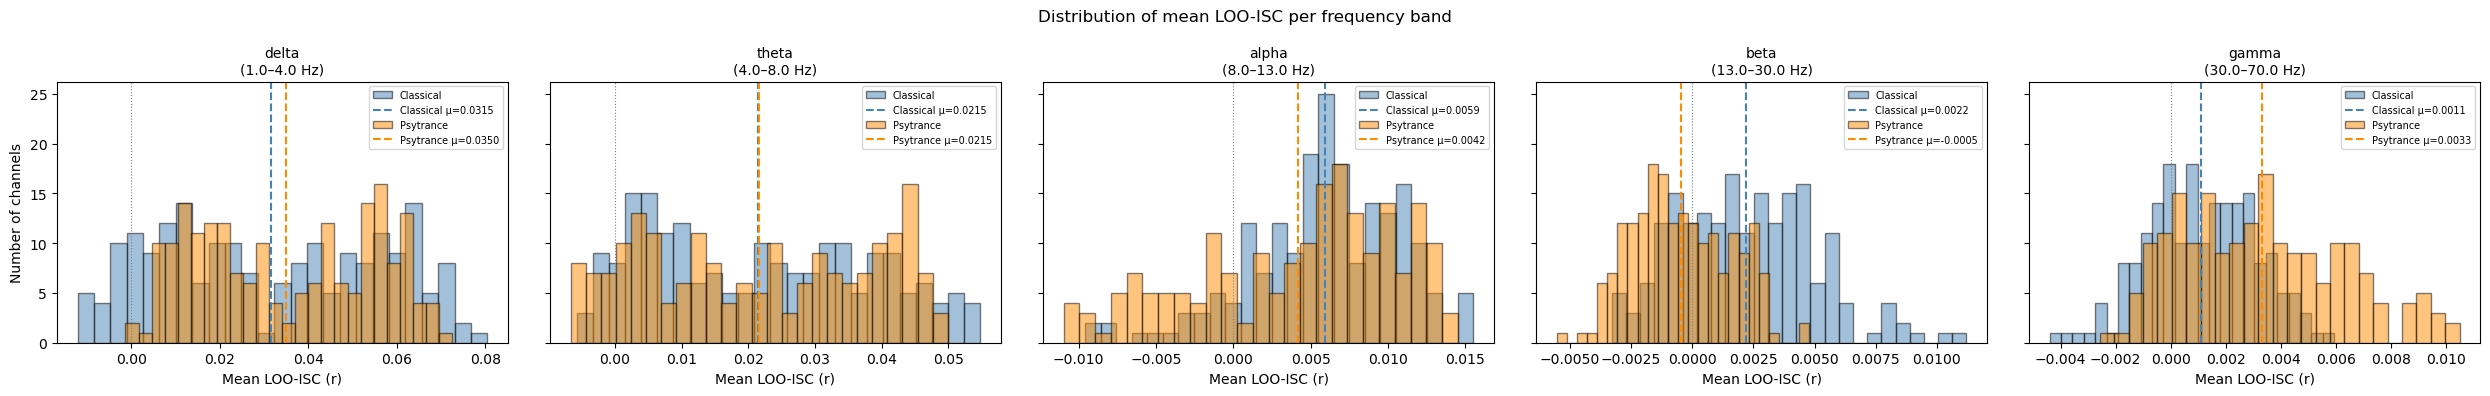

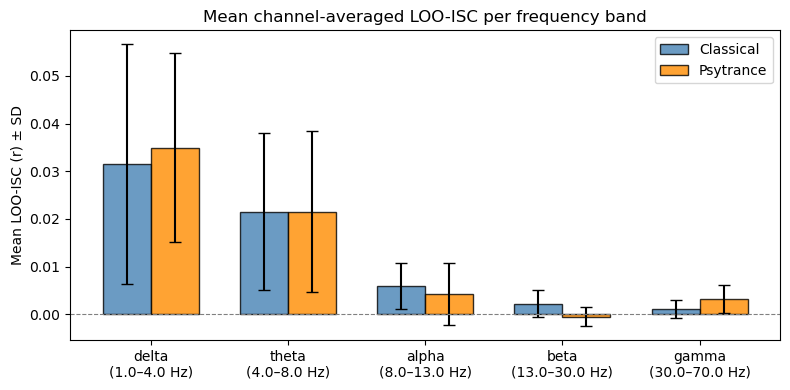

In [ ]:
_first_ad = next(iter(datasets.values()))

plot_band_isc_distributions(
    band_iscs,
    bands=FREQUENCY_BANDS,
    feature_axis_label=f"Number of {_first_ad.feature_axis_label.lower()}s",
    save_path=SAVE_DIR / "band_isc_distributions.png",
)
plot_band_mean_isc_bar(
    band_iscs,
    bands=FREQUENCY_BANDS,
    save_path=SAVE_DIR / "band_isc_mean_bar.png",
)

## Band-specific Sliding-Window ISC (Time-Resolved Synchrony per Band)

The same sliding-window approach (5 s / 2.5 s step) applied to each
frequency band independently.  This shows **when** and **in which rhythm**
listeners' brains are most synchronised.


In [ ]:
# Compute sliding-window ISC per band for all datasets
band_sw: dict = {}
for label, ad in datasets.items():
    print(f"Computing band sliding-window ISC for {label} …")
    band_sw[label] = {}
    for band, (l_freq, h_freq) in FREQUENCY_BANDS.items():
        filtered = ad.filter_to_band(l_freq, h_freq)
        tc, times = compute_sliding_window_isc(
            filtered.data, window_sec=WINDOW_SEC, step_sec=STEP_SEC, sfreq=ad.sfreq
        )
        band_sw[label][band] = (tc, times)
        print(f"  {band:6s}  isc_tc={tc.shape}  times={times.shape}")
    print()

Computing band sliding-window ISC for Classical …
  delta   isc_tc=(145, 195)  times=(145,)
  theta   isc_tc=(145, 195)  times=(145,)
  alpha   isc_tc=(145, 195)  times=(145,)
  beta    isc_tc=(145, 195)  times=(145,)
  gamma   isc_tc=(145, 195)  times=(145,)

Computing band sliding-window ISC for Psytrance …
  delta   isc_tc=(192, 195)  times=(192,)
  theta   isc_tc=(192, 195)  times=(192,)
  alpha   isc_tc=(192, 195)  times=(192,)
  beta    isc_tc=(192, 195)  times=(192,)
  gamma   isc_tc=(192, 195)  times=(192,)



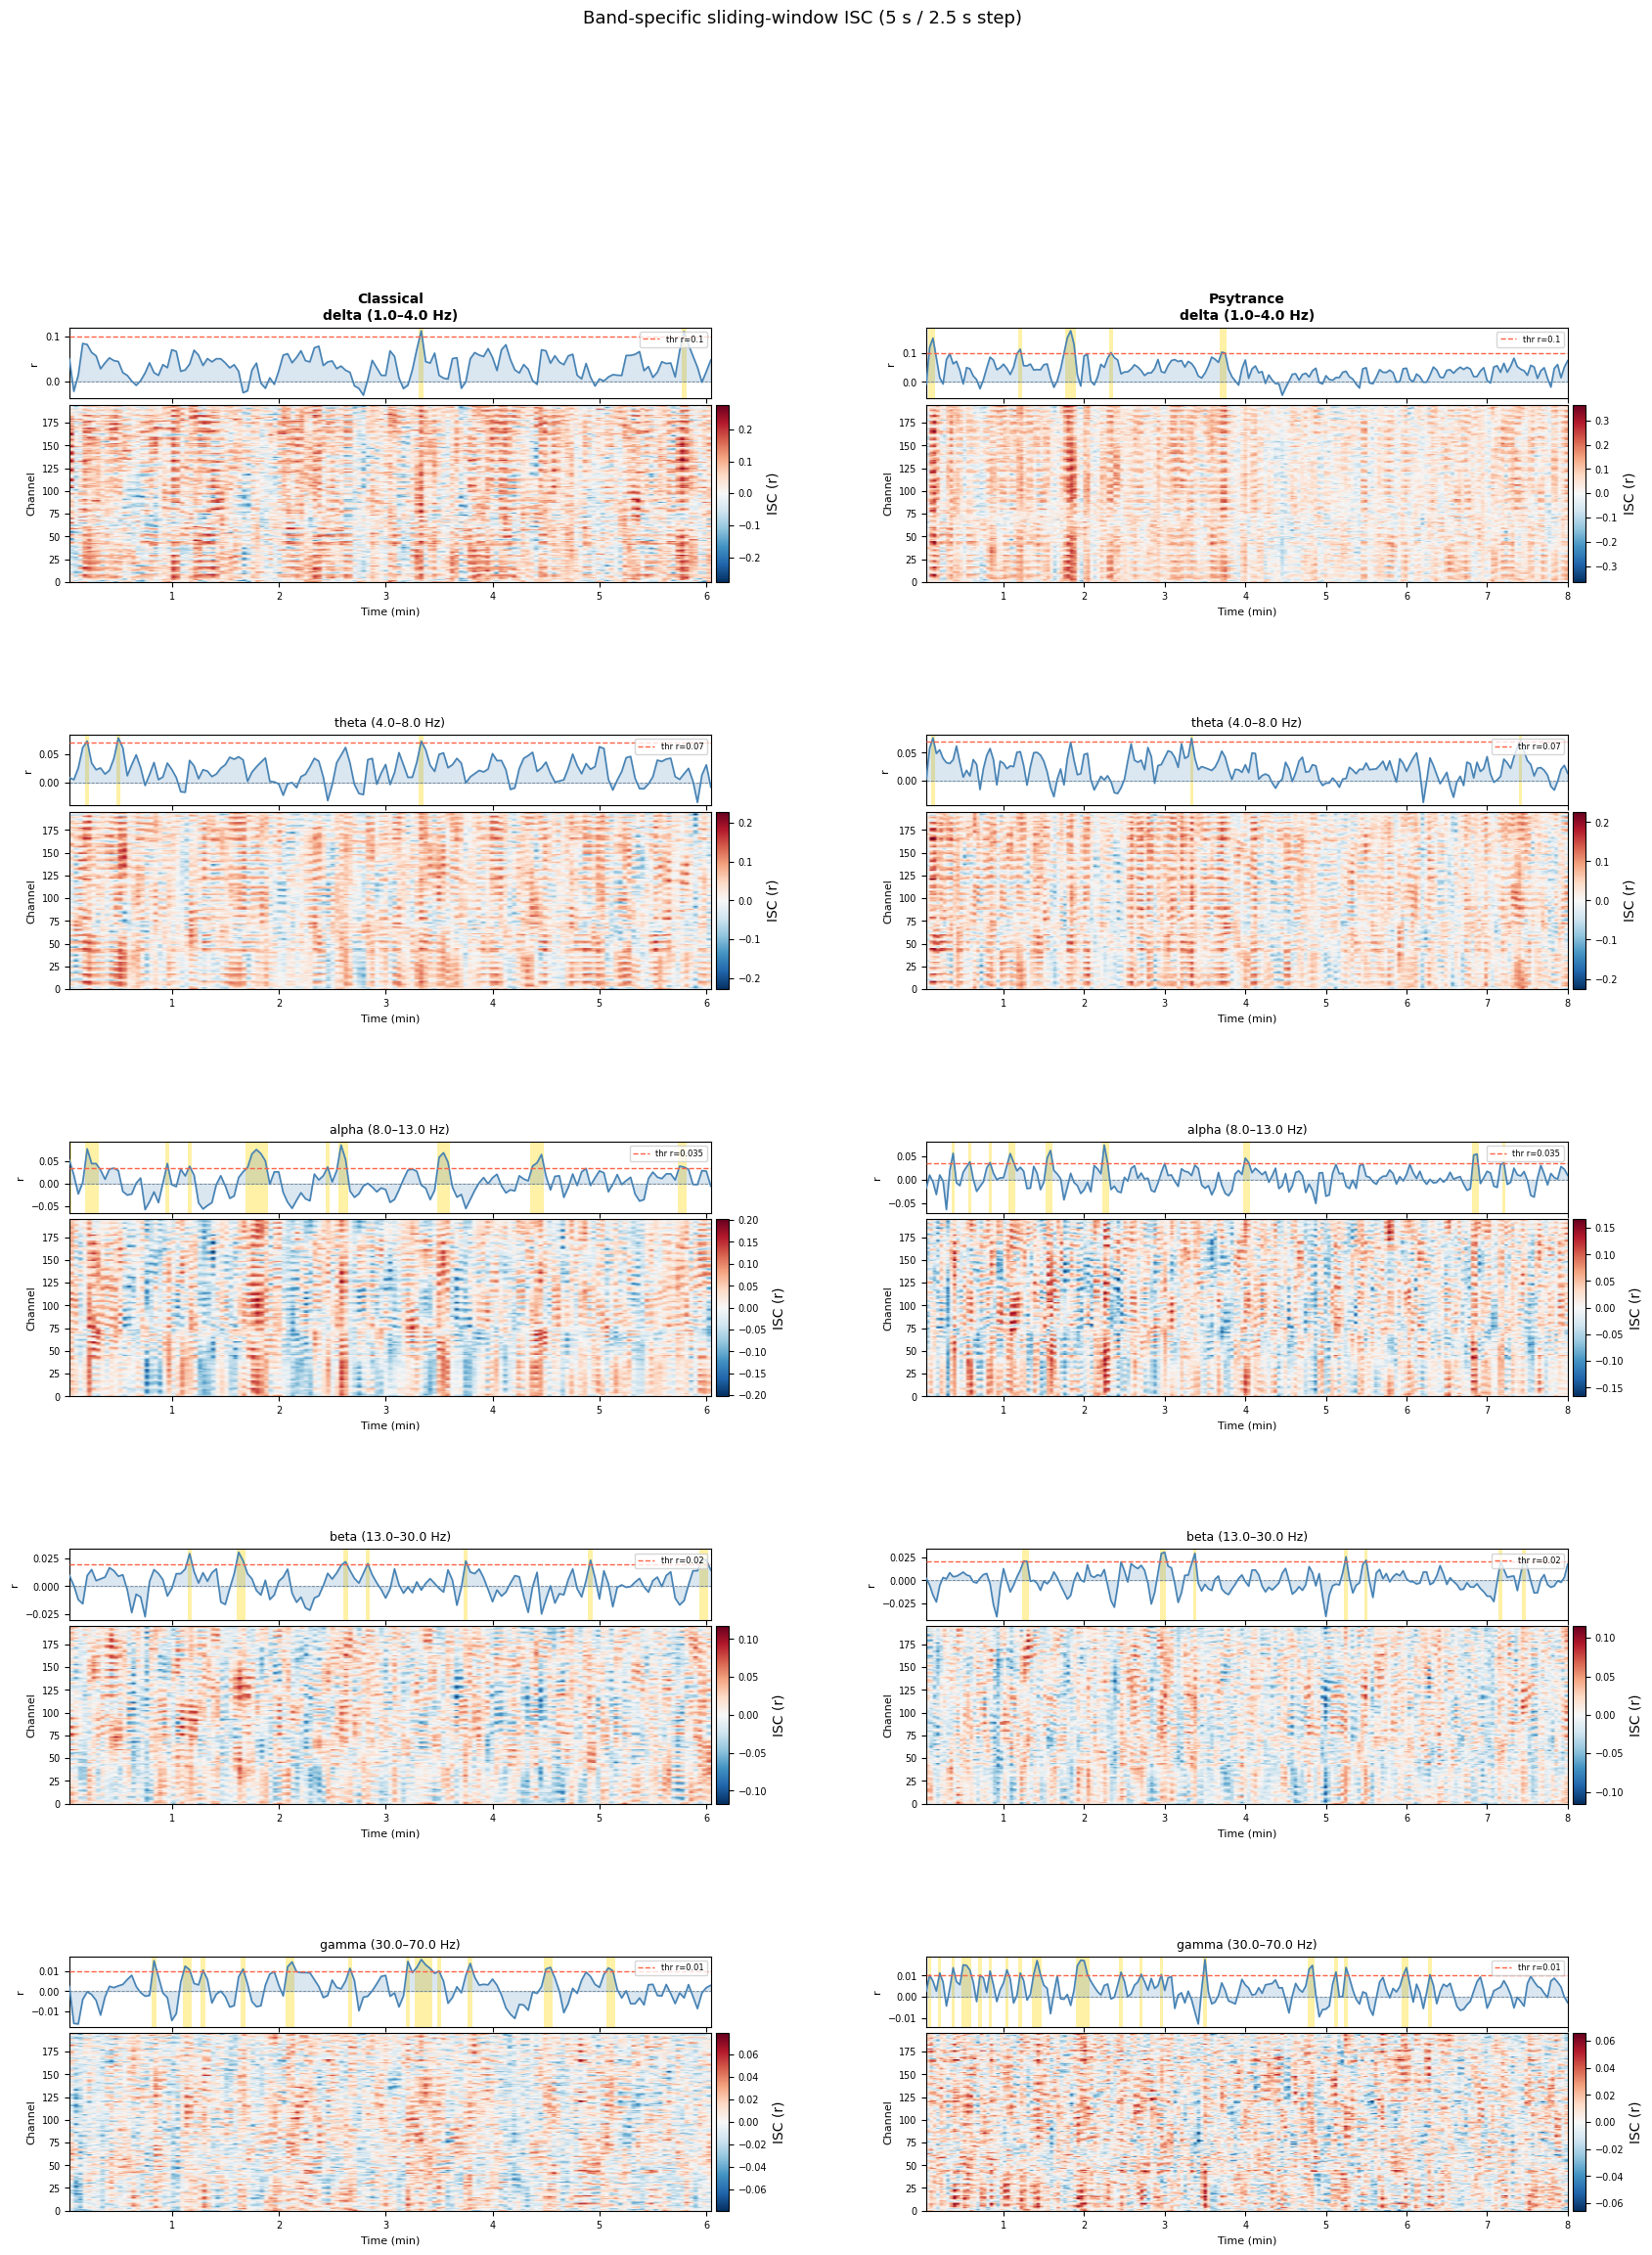

In [ ]:
plot_band_sliding_window_isc(
    band_sw,
    bands=FREQUENCY_BANDS,
    isc_threshold=BAND_ISC_THRESHOLDS,
    feature_axis_label=_first_ad.feature_axis_label,
    save_path=SAVE_DIR / "band_sliding_window_isc.png",
)

In [ ]:
# Print contiguous significant intervals per band for all datasets
print_band_significant_intervals(
    band_sw,
    bands=FREQUENCY_BANDS,
    band_thresholds=BAND_ISC_THRESHOLDS,
    default_threshold=ISC_THRESHOLD,
)

  Classical

  delta (1.0–4.0 Hz)  |  sig windows: 77/145 (53.1 %)
    #  Start(min)   End(min)   Dur(s)    Mean r    Peak r
  --------------------------------------------------------
    1       0.021      0.062      2.5    0.0502    0.0502
    2       0.146      0.312     10.0    0.0717    0.0841
    3       0.354      0.521     10.0    0.0458    0.0522
    4       0.771      0.812      2.5    0.0412    0.0412
    5       0.896      0.938      2.5    0.0372    0.0372
    6       0.979      1.062      5.0    0.0684    0.0702
    7       1.146      1.521     22.5    0.0485    0.0691
    8       1.562      1.604      2.5    0.0370    0.0370
    9       1.771      1.812      2.5    0.0406    0.0406
   10       2.021      2.521     30.0    0.0540    0.0780
   11       2.854      2.896      2.5    0.0466    0.0466
   12       3.021      3.104      5.0    0.0615    0.0676
   13       3.271      3.479     12.5    0.0661    0.1124
   14       3.604      3.688      5.0    0.0516    0.0525
   1

## Band Overlap — Consensus Synchrony Windows

For each music type: which time windows are simultaneously significant across multiple bands,
and how many bands agree at each point.  The top panel is a binary raster (one row per band,
filled where the mean ISC exceeds its threshold).  The bottom panel shows the per-window band
count, making it easy to spot intervals where several rhythms synchronise together — prime
candidates for deeper analysis.


/tmp/ipykernel_717888/1746793724.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_count = cm.get_cmap("YlOrRd", n_rows + 1)


[Classical] ALL-rows simultaneous windows: 0/145 (0.0 %)


/tmp/ipykernel_717888/1746793724.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_count = cm.get_cmap("YlOrRd", n_rows + 1)
/tmp/ipykernel_717888/1746793724.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[Psytrance] ALL-rows simultaneous windows: 0/192 (0.0 %)


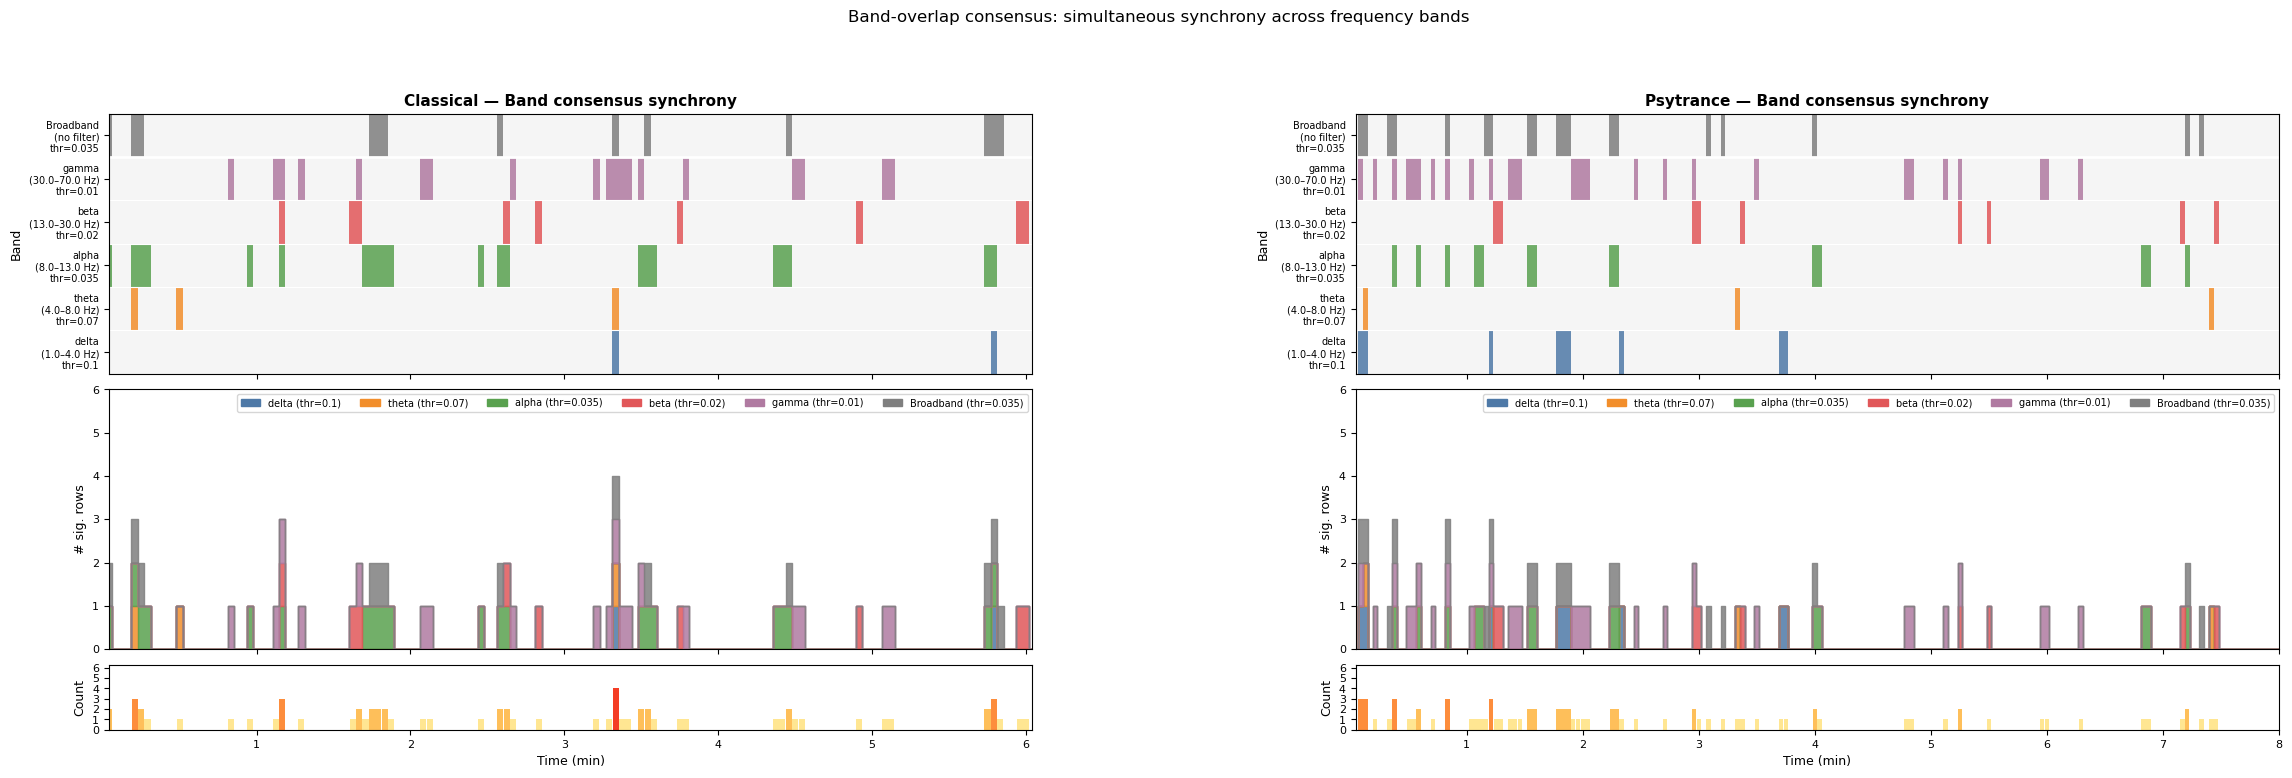

In [ ]:
plot_band_overlap(
    band_sw,
    bands=FREQUENCY_BANDS,
    band_thresholds=BAND_ISC_THRESHOLDS,
    broadband_sw=sw_results,
    broadband_threshold=ISC_THRESHOLD,
    save_path=SAVE_DIR / "band_overlap.png",
)